# echofac2 v2: Preprocessing dengan TRUE Tgram

**Perbedaan dari v1:**
- Branch 0: Log-Mel Spectrogram (1024 FFT)
- Branch 1: **Tgram = MFCC + Delta (temporal dynamics)** — informasi BERBEDA dari Mel

MFCC+Delta lebih merepresentasikan dinamika temporal suara mesin,
sementara Mel Spectrogram merepresentasikan konten frekuensi statis.

In [1]:
import os, gc, glob, json
import numpy as np
import librosa
import torch
import torch.nn.functional as F
from tqdm import tqdm
print(f'torch {torch.__version__} | librosa {librosa.__version__}')


torch 2.10.0+cpu | librosa 0.11.0


In [2]:
# Path dari notebook kamu — JANGAN DIUBAH
DATASET_ROOT = '/kaggle/input/datasets/bisheshgiri/mimii-dataset'
OUT_DIR      = '/kaggle/working'
TARGET_SNR   = '0_dB'
MACHINE_TYPES = ['fan',]
SR            = 16000
IMG_SIZE      = (128, 128)

# Branch 0: Mel Spectrogram
MEL_N_MELS, MEL_N_FFT, MEL_HOP = 128, 1024, 512

# Branch 1: MFCC + Delta (n_mfcc x 3 channels digabung -> resize ke 128x128)
MFCC_N       = 40
MFCC_HOP     = 512

os.makedirs(f'{OUT_DIR}/features', exist_ok=True)
print('Config OK | Dual-branch: [Mel Spectrogram] + [MFCC+Delta (temporal)]')


Config OK | Dual-branch: [Mel Spectrogram] + [MFCC+Delta (temporal)]


In [3]:
def compute_mel(wav):
    mel = librosa.feature.melspectrogram(
        y=wav, sr=SR, n_mels=MEL_N_MELS, n_fft=MEL_N_FFT, hop_length=MEL_HOP
    )
    return librosa.power_to_db(mel, ref=np.max)

def compute_tgram(wav):
    """
    TRUE Tgram: MFCC + Delta + Delta-Delta digabung menjadi representasi temporal.
    - MFCC (40 coeff): representasi spektral kompak
    - Delta: kecepatan perubahan (temporal dynamics)
    - Delta-Delta: akselerasi perubahan
    Gabungkan sebagai 3 channel -> average -> 1 channel temporal map
    """
    mfcc       = librosa.feature.mfcc(y=wav, sr=SR, n_mfcc=MFCC_N, hop_length=MFCC_HOP)
    delta1     = librosa.feature.delta(mfcc, order=1)
    delta2     = librosa.feature.delta(mfcc, order=2)
    # Stack & normalize masing-masing, lalu rata-ratakan
    def norm(x): return (x - x.mean()) / (x.std() + 1e-8)
    tgram = (norm(mfcc) + norm(delta1) + norm(delta2)) / 3.0
    return tgram  # [40, T]

def normalize(x):
    return (x - x.mean()) / (x.std() + 1e-8)

def to_tensor(x_np):
    t = torch.FloatTensor(x_np).unsqueeze(0).unsqueeze(0)
    return F.interpolate(t, size=IMG_SIZE, mode='bilinear', align_corners=False).squeeze(0)

def extract_features(wav_path):
    wav = librosa.load(wav_path, sr=SR, mono=True)[0]
    mel_feat = to_tensor(normalize(compute_mel(wav)))
    tg_feat  = to_tensor(compute_tgram(wav))      # sudah dinormalisasi di dalam
    return torch.cat([mel_feat, tg_feat], dim=0)  # [2, 128, 128]

# Verifikasi
test_files = glob.glob(f'{DATASET_ROOT}/0_dB_fan/fan/id_00/normal/*.wav')
if test_files:
    feat = extract_features(test_files[0])
    print(f'Feature shape: {feat.shape}  (expected: [2, 128, 128])')
    print(f'Branch 0 (Mel):        mean={feat[0].mean():.3f}, std={feat[0].std():.3f}')
    print(f'Branch 1 (MFCC+Delta): mean={feat[1].mean():.3f}, std={feat[1].std():.3f}')
    print(f'Correlation antar branch: {torch.corrcoef(torch.stack([feat[0].flatten(), feat[1].flatten()]))[0,1]:.3f}')
    print('(Korelasi HARUS < 0.7 untuk dual-branch berguna)')


Feature shape: torch.Size([2, 128, 128])  (expected: [2, 128, 128])
Branch 0 (Mel):        mean=-0.001, std=0.992
Branch 1 (MFCC+Delta): mean=-0.000, std=0.470
Correlation antar branch: -0.114
(Korelasi HARUS < 0.7 untuk dual-branch berguna)


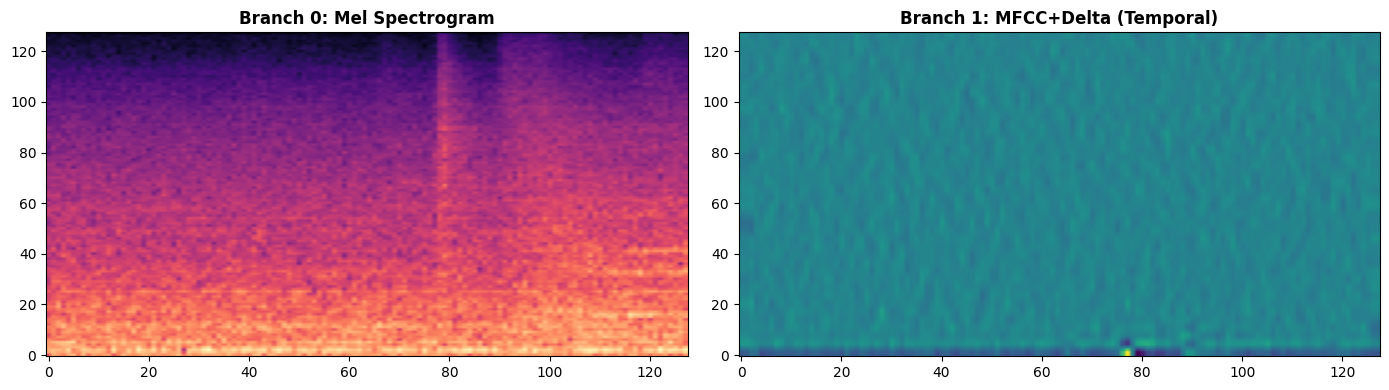

Kedua branch HARUS terlihat berbeda!


In [4]:
import matplotlib.pyplot as plt
if test_files:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].imshow(feat[0].numpy(), aspect='auto', origin='lower', cmap='magma')
    axes[0].set_title('Branch 0: Mel Spectrogram', fontweight='bold')
    axes[1].imshow(feat[1].numpy(), aspect='auto', origin='lower', cmap='viridis')
    axes[1].set_title('Branch 1: MFCC+Delta (Temporal)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/feature_branches_v2.png', dpi=150)
    plt.show()
    print('Kedua branch HARUS terlihat berbeda!')


In [5]:
label_maps = {}
for m in MACHINE_TYPES:
    mp = os.path.join(DATASET_ROOT, f'{TARGET_SNR}_{m}', m)
    if not os.path.exists(mp): continue
    ids = sorted(os.listdir(mp))
    label_maps[m] = {mid: i for i, mid in enumerate(ids)}
    print(f'  {m}: {label_maps[m]}')
with open('/kaggle/working/label_maps.json', 'w') as f:
    json.dump(label_maps, f, indent=2)
print('Label maps saved.')


  fan: {'id_00': 0, 'id_02': 1, 'id_04': 2, 'id_06': 3}
Label maps saved.


In [6]:
for machine in MACHINE_TYPES:
    print(f'\nProcessing {machine.upper()}...')
    lmap = label_maps.get(machine, {})
    mp   = os.path.join(DATASET_ROOT, f'{TARGET_SNR}_{machine}', machine)
    if not os.path.exists(mp):
        print(f'  SKIP: {mp} tidak ada'); continue

    for condition in ['normal', 'abnormal']:
        all_feats, all_labels, all_paths = [], [], []
        for mid, label_id in lmap.items():
            cp    = os.path.join(mp, mid, condition)
            if not os.path.exists(cp): continue
            files = sorted(glob.glob(os.path.join(cp, '*.wav')))
            print(f'  {mid}/{condition}: {len(files)} files')
            for fp in tqdm(files, desc=mid, leave=False):
                try:
                    all_feats.append(extract_features(fp))
                    all_labels.append(label_id)
                    all_paths.append(fp)
                except Exception as e:
                    print(f'  Skip {os.path.basename(fp)}: {e}')

        if not all_feats: continue
        save_path = f'/kaggle/working/features/{machine}_{condition}.pt'
        torch.save({'features': torch.stack(all_feats), 'labels': torch.LongTensor(all_labels), 'paths': all_paths}, save_path)
        mb = os.path.getsize(save_path) / (1024**2)
        print(f'  SAVED: {save_path} | Shape: {torch.stack(all_feats).shape} | {mb:.1f} MB')
        del all_feats, all_labels, all_paths; gc.collect()

    print(f'{machine.upper()} DONE')
print('\nechofac2 v2 SELESAI! -> Lanjut ke echofac3 v2')



Processing FAN...
  id_00/normal: 1011 files


  id_02/normal: 1016 files


  id_04/normal: 1033 files


  id_06/normal: 1015 files


  SAVED: /kaggle/working/features/fan_normal.pt | Shape: torch.Size([4075, 2, 128, 128]) | 509.8 MB
  id_00/abnormal: 407 files


  id_02/abnormal: 359 files


  id_04/abnormal: 348 files


  id_06/abnormal: 361 files


  SAVED: /kaggle/working/features/fan_abnormal.pt | Shape: torch.Size([1475, 2, 128, 128]) | 184.5 MB
FAN DONE

echofac2 v2 SELESAI! -> Lanjut ke echofac3 v2
